In [1]:
import os

os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"

# Compatibility patch for newer protobuf versions
try:
    from google.protobuf import message_factory

    if not hasattr(message_factory.MessageFactory, "GetPrototype"):

        def _GetPrototype(self, descriptor):
            return self.GetMessageClass(descriptor)

        message_factory.MessageFactory.GetPrototype = _GetPrototype
except Exception:
    pass

import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import KFold
import pydicom




2026-05-07 15:15:19.639813: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778166919.652233      55 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778166919.656121      55 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-07 15:15:19.670401: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
def seed_everything(seed=2020):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


seed_everything(42)



In [3]:
train = pd.read_csv("../input/osic-pulmonary-fibrosis-progression/train.csv")
test = pd.read_csv("../input/osic-pulmonary-fibrosis-progression/test.csv")
sub = pd.read_csv("../input/osic-pulmonary-fibrosis-progression/sample_submission.csv")
print(train.head())
print(test.head())
print(sub.head())



                     Patient  Weeks   FVC    Percent  Age   Sex SmokingStatus
0  ID00133637202223847701934     -2  3195  92.856312   83  Male  Never smoked
1  ID00133637202223847701934      2  3203  93.088817   83  Male  Never smoked
2  ID00133637202223847701934      4  3097  90.008138   83  Male  Never smoked
3  ID00133637202223847701934      6  3171  92.158800   83  Male  Never smoked
4  ID00133637202223847701934      8  3115  90.531272   83  Male  Never smoked
                     Patient  Weeks   FVC    Percent  Age     Sex  \
0  ID00014637202177757139317      0  3807  90.076661   56    Male   
1  ID00019637202178323708467     13  2100  92.858722   83  Female   
2  ID00047637202184938901501      2  3313  89.929425   68    Male   
3  ID00082637202201836229724     19  2918  99.794802   49  Female   
4  ID00126637202218610655908     18  2375  59.375000   78    Male   

      SmokingStatus  
0         Ex-smoker  
1         Ex-smoker  
2         Ex-smoker  
3  Currently smokes  
4      

In [4]:
train.drop_duplicates(keep=False, inplace=True, subset=["Patient", "Weeks"])

sub["Patient"] = sub["Patient_Week"].apply(lambda x: x.split("_")[0])
sub["Weeks"] = sub["Patient_Week"].apply(lambda x: int(x.split("_")[-1]))
sub = sub[["Patient", "Weeks", "Confidence", "Patient_Week"]]
sub = sub.merge(test.drop("Weeks", axis=1), on="Patient")

print(train.shape, test.shape, sub.shape)



(1380, 7) (18, 7) (1908, 9)


In [5]:
print(train.info())



<class 'pandas.core.frame.DataFrame'>
Index: 1380 entries, 0 to 1391
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Patient        1380 non-null   object 
 1   Weeks          1380 non-null   int64  
 2   FVC            1380 non-null   int64  
 3   Percent        1380 non-null   float64
 4   Age            1380 non-null   int64  
 5   Sex            1380 non-null   object 
 6   SmokingStatus  1380 non-null   object 
dtypes: float64(1), int64(3), object(3)
memory usage: 86.2+ KB
None


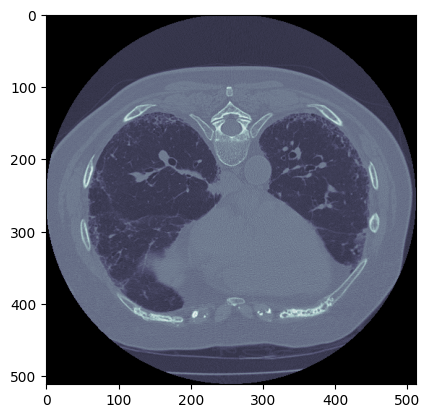

In [6]:
image_path = "../input/osic-pulmonary-fibrosis-progression/"
image_files_list = []
for dirName, subdirList, fileList in os.walk(image_path):
    for filename in fileList:
        if ".dcm" in filename.lower():
            image_files_list.append(os.path.join(dirName, filename))


image = pydicom.dcmread(image_files_list[0])

plt.figure()
plt.imshow(image.pixel_array, cmap=plt.cm.bone)



In [7]:
train["WHERE"] = "train"
test["WHERE"] = "val"
sub["WHERE"] = "test"

data = pd.concat([train, test, sub], ignore_index=True)

data["min_week"] = data["Weeks"]
data.loc[data.WHERE == "test", "min_week"] = np.nan
data["min_week"] = data.groupby("Patient")["min_week"].transform("min")

base = data.loc[data.Weeks == data.min_week]
base = base[["Patient", "FVC"]].copy()
base.columns = ["Patient", "min_FVC"]
base["nb"] = 1
base["nb"] = base.groupby("Patient")["nb"].transform("cumsum")
base = base[base.nb == 1]
base.drop("nb", axis=1, inplace=True)

data = data.merge(base, on="Patient", how="left")
data["base_week"] = data["Weeks"] - data["min_week"]
del base

COLS = ["Sex", "SmokingStatus"]
FE = []
for col in COLS:
    for mod in data[col].unique():
        FE.append(mod)
        data[mod] = (data[col] == mod).astype(int)

data["age"] = (data["Age"] - data["Age"].min()) / (
    data["Age"].max() - data["Age"].min()
)
data["BASE"] = (data["min_FVC"] - data["min_FVC"].min()) / (
    data["min_FVC"].max() - data["min_FVC"].min()
)
data["week"] = (data["base_week"] - data["base_week"].min()) / (
    data["base_week"].max() - data["base_week"].min()
)
data["percent"] = (data["Percent"] - data["Percent"].min()) / (
    data["Percent"].max() - data["Percent"].min()
)
FE += ["age", "percent", "week", "BASE"]
print(FE)

train = data.loc[data.WHERE == "train"]
test = data.loc[data.WHERE == "val"]
sub = data.loc[data.WHERE == "test"]
del data

print(train.shape, test.shape, sub.shape)



['Male', 'Female', 'Never smoked', 'Ex-smoker', 'Currently smokes', 'age', 'percent', 'week', 'BASE']
(1380, 22) (18, 22) (1908, 22)


In [8]:
C1, C2 = tf.constant(70, dtype="float32"), tf.constant(1000, dtype="float32")


def score(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    sigma = y_pred[:, 2] - y_pred[:, 0]
    fvc_pred = y_pred[:, 1]
    sigma_clip = tf.maximum(sigma, C1)
    delta = tf.abs(y_true[:, 0] - fvc_pred)
    delta = tf.minimum(delta, C2)
    sq2 = tf.sqrt(tf.constant(2.0, dtype=tf.float32))
    metric = (delta / sigma_clip) * sq2 + tf.math.log(sigma_clip * sq2)
    return tf.keras.backend.mean(metric)


def qloss(y_true, y_pred):
    qs = [0.2, 0.50, 0.8]
    q = tf.constant(np.array([qs]), dtype=tf.float32)
    e = y_true - y_pred
    v = tf.maximum(q * e, (q - 1) * e)
    return tf.keras.backend.mean(v)


def mloss(_lambda):
    def loss(y_true, y_pred):
        return _lambda * qloss(y_true, y_pred) + (1 - _lambda) * score(y_true, y_pred)

    return loss


def make_model(nh):
    z = tf.keras.layers.Input((nh,), name="Patient")
    x = tf.keras.layers.Dense(120, activation="relu", name="d1")(z)
    x = tf.keras.layers.Dense(120, activation="relu", name="d2")(x)
    p1 = tf.keras.layers.Dense(3, activation="linear", name="p1")(x)
    p2 = tf.keras.layers.Dense(3, activation="relu", name="p2")(x)
    preds = tf.keras.layers.Lambda(
        lambda x: x[0] + tf.cumsum(x[1], axis=1), name="preds"
    )([p1, p2])
    model = tf.keras.models.Model(z, preds, name="definitely_not_a_CNN")
    model.compile(
        loss=mloss(0.8),
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001, beta_1=0.9, beta_2=0.999
        ),
        metrics=[score],
    )
    return model




2026-05-07 15:15:27.251534: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1778166927.251955      55 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46866 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:85:00.0, compute capability: 8.6


In [9]:
y = train["FVC"].values.reshape(-1, 1)  # reshape for custom loss
z = train[FE].values
ze = sub[FE].values
nh = z.shape[1]
pe = np.zeros((ze.shape[0], 3))
pred = np.zeros((z.shape[0], 3))

net = make_model(nh)
print(net.summary())
print("Total params:", net.count_params())



Model: "definitely_not_a_CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Patient             │ (None, 9)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ d1 (Dense)          │ (None, 120)       │      1,200 │ Patient[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ d2 (Dense)          │ (None, 120)       │     14,520 │ d1[0][0]          │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ p1 (Dense)          │ (None, 3)         │        363 │ d2[0][0]          │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ p2 (Dense)          │ (None, 3)         │        363 │ d2[0][0]          │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ preds (Lambda)      │ (None, 3)         │          0 │ p1[0][0],         │
│                     │                   │            │ p2[0][0]          │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 16,446 (64.24 KB)

 Trainable params: 16,446 (64.24 KB)

 Non-trainable params: 0 (0.00 B)

None
Total params: 16446


In [10]:
NFOLD = 5
kf = KFold(n_splits=NFOLD, shuffle=True, random_state=42)

cnt = 0
EPOCHS = 800
BATCH_SIZE = 64
diff_sum = 0.0

for tr_idx, val_idx in kf.split(z):
    cnt += 1
    print(f"FOLD {cnt}")
    net = make_model(nh)
    net.fit(
        z[tr_idx],
        y[tr_idx],
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        validation_data=(z[val_idx], y[val_idx]),
        verbose=0,
    )
    train_loss, train_score = net.evaluate(
        z[tr_idx], y[tr_idx], verbose=0, batch_size=BATCH_SIZE
    )
    print(f"Train Loss: {train_loss:.4f}  Score: {train_score:.4f}")
    val_loss, val_score = net.evaluate(
        z[val_idx], y[val_idx], verbose=0, batch_size=BATCH_SIZE
    )
    print(f"Val Loss: {val_loss:.4f}  Score: {val_score:.4f}")
    score_diff = val_score - train_score
    diff_sum += score_diff
    print(f"Score diff: {score_diff:.4f}")
    print("Predict val...")
    pred[val_idx] = net.predict(z[val_idx], batch_size=BATCH_SIZE, verbose=0)
    print("Predict test...")
    pe += net.predict(ze, batch_size=BATCH_SIZE, verbose=0) / NFOLD

print(f"Score diff sum : {diff_sum:.4f}")



FOLD 1


I0000 00:00:1778166928.951806     113 service.cc:148] XLA service 0x7facd400ac50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778166928.951832     113 service.cc:156]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2026-05-07 15:15:28.974137: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778166929.070732     113 cuda_dnn.cc:529] Loaded cuDNN version 90300
2026-05-07 15:15:31.160052: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_472', 84 bytes spill stores, 84 bytes spill loads

I0000 00:00:1778166931.999834     113 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Train Loss: 41.4555  Score: 6.5112
Val Loss: 43.2224  Score: 6.5462
Score diff: 0.0350
Predict val...
Predict test...


2026-05-07 15:16:28.769909: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_18', 8 bytes spill stores, 8 bytes spill loads



FOLD 2
Train Loss: 43.2962  Score: 6.5779
Val Loss: 38.6241  Score: 6.4697
Score diff: -0.1083
Predict val...
Predict test...
FOLD 3
Train Loss: 41.8730  Score: 6.5212
Val Loss: 43.4046  Score: 6.5590
Score diff: 0.0379
Predict val...
Predict test...
FOLD 4
Train Loss: 42.1921  Score: 6.5476
Val Loss: 42.4937  Score: 6.5642
Score diff: 0.0166
Predict val...
Predict test...
FOLD 5
Train Loss: 41.5749  Score: 6.5291
Val Loss: 46.9892  Score: 6.6281
Score diff: 0.0990
Predict val...
Predict test...
Score diff sum : 0.0803


In [11]:
sigma_opt = mean_absolute_error(y, pred[:, 1])
unc = pred[:, 2] - pred[:, 0]
sigma_mean = np.mean(unc)

sub["FVC1"] = 0.996 * pe[:, 1]
sub["Confidence1"] = pe[:, 2] - pe[:, 0]
subm = sub[["Patient_Week", "FVC", "Confidence", "FVC1", "Confidence1"]].copy()

subm.loc[~subm.FVC1.isnull(), "FVC"] = subm.loc[~subm.FVC1.isnull(), "FVC1"]
if sigma_mean < 70:
    subm["Confidence"] = sigma_opt
else:
    subm.loc[~subm.FVC1.isnull(), "Confidence"] = subm.loc[
        ~subm.FVC1.isnull(), "Confidence1"
    ]



/tmp/ipykernel_55/1214660150.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[2289.56776611 2287.32561108 2285.21512939 ... 3129.60197168 3127.49465112
 3125.52417114]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  subm.loc[~subm.FVC1.isnull(), "FVC"] = subm.loc[~subm.FVC1.isnull(), "FVC1"]


In [12]:
otest = pd.read_csv("../input/osic-pulmonary-fibrosis-progression/test.csv")
for i in range(len(otest)):
    key = f"{otest.Patient[i]}_{otest.Weeks[i]}"
    subm.loc[subm["Patient_Week"] == key, "FVC"] = otest.FVC[i]
    subm.loc[subm["Patient_Week"] == key, "Confidence"] = 0.1

subm[["Patient_Week", "FVC", "Confidence"]].to_csv("submission.csv", index=False)